# NEO Hazardous Classification with a Feature-Reuploading QNN

This notebook trains a PennyLane + PyTorch quantum neural network to predict whether a near-Earth object is hazardous, then compares it against a small classical Torch neural network trained on the exact same tensors.

The QNN uses a hybrid quantum-classical architecture: the circuit produces per-wire Pauli-Z expectations, which are combined by a trainable `Linear(n_qubits, 1)` readout head into a single logit. Trainable parameters therefore include both the ansatz angles `theta` and the readout weights. In the current configuration (`USE_PCA = False`), the six engineered tabular features are standardized, scaled as rotation angles, and passed into a 6-qubit circuit. If `USE_PCA` is switched on, the same preprocessing cell reduces the standardized features to 4 PCA components before angle scaling.

`FEATURE_REUPLOADS` controls how many times the notebook applies the `feature map -> ansatz` block. Use an integer to train one QNN, or a list such as `[1, 2, 3]` to compare depths.

## 1. Imports and Dataset Loading

In [65]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn import metrics

# Preload CUDA 13 NVRTC builtins so PennyLane/Torch CUDA kernels can JIT-compile.
# torch's libnvrtc.so.13 calls dlopen("libnvrtc-builtins.so.13.0") without searching
# torch/lib, so we resolve and load it explicitly here.
import ctypes, os
for _candidate in (
    os.path.join(os.path.dirname(torch.__file__), "lib", "libnvrtc-builtins.so.13.0"),
    "/home/pennati/phd/quantum/quantumPyCPU311/lib/python3.11/site-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0",
):
    if os.path.exists(_candidate):
        ctypes.CDLL(_candidate, mode=ctypes.RTLD_GLOBAL)
        break

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 17,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

cuda_available = torch.cuda.is_available()
torch_device = torch.device("cuda" if cuda_available else "cpu")

if cuda_available:
    torch.cuda.manual_seed_all(SEED)

csv_path = Path("/home/pennati/phd/quantum_machine_learning/project/data/neo.csv")
dataset = pd.read_csv(csv_path)

print(f"PennyLane version: {qml.__version__}")
print(f"Torch version:     {torch.__version__}")
print(f"Torch CUDA:        {torch.version.cuda}")
print(f"CUDA available:    {cuda_available}")
print(f"QNN Torch device:  {torch_device}")
print(f"Dataset shape:     {dataset.shape}")
print(f"Loaded dataset from: {csv_path.resolve()}")

dataset.head()

PennyLane version: 0.44.1
Torch version:     2.9.1+cu130
Torch CUDA:        13.0
CUDA available:    True
QNN Torch device:  cuda
Dataset shape:     (90836, 10)
Loaded dataset from: /home/pennati/phd/quantum_machine_learning/project/data/neo.csv


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.1983,2.6794,"13,569.2492","54,839,744.0828",Earth,False,16.7300,False
1,2277475,277475 (2005 WK4),0.2658,0.5943,"73,588.7267","61,438,126.5240",Earth,False,20.0000,True
2,2512244,512244 (2015 YE18),0.7220,1.6145,"114,258.6921","49,798,724.9405",Earth,False,17.8300,False
3,3596030,(2012 BV13),0.0965,0.2158,"24,764.3031","25,434,972.7208",Earth,False,22.2000,False
4,3667127,(2014 GE35),0.2550,0.5702,"42,737.7338","46,275,567.0013",Earth,False,20.0900,True


## 2. Cleaning and Target Inspection

Missing values per column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64
Duplicate rows: 0


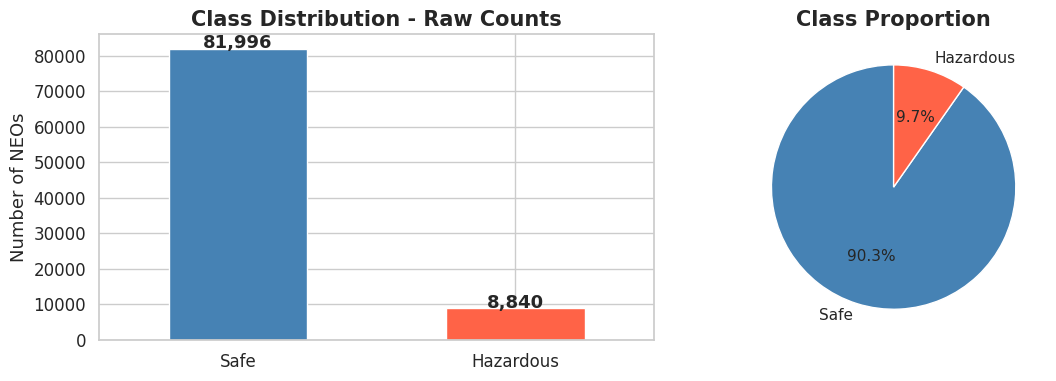

Hazardous: 8,840 (9.7%)
Safe:      81,996 (90.3%)
Imbalance ratio (safe : hazardous): 9.3 : 1


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.1983,2.6794,"13,569.2492","54,839,744.0828",16.7300,False
1,0.2658,0.5943,"73,588.7267","61,438,126.5240",20.0000,True
2,0.7220,1.6145,"114,258.6921","49,798,724.9405",17.8300,False
3,0.0965,0.2158,"24,764.3031","25,434,972.7208",22.2000,False
4,0.2550,0.5702,"42,737.7338","46,275,567.0013",20.0900,True


In [66]:
print("Missing values per column:")
print(dataset.isnull().sum())
print(f"Duplicate rows: {dataset.duplicated().sum():,}")

df_clean = dataset.drop(columns=["id", "name", "orbiting_body", "sentry_object"]).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean["hazardous"].value_counts().sort_index()
counts.index = ["Safe", "Hazardous"]
counts.plot(kind="bar", ax=ax1, color=["steelblue", "tomato"])
ax1.set_title("Class Distribution - Raw Counts", fontweight="bold")
ax1.set_ylabel("Number of NEOs")
ax1.tick_params(axis="x", rotation=0)
for i, value in enumerate(counts):
    ax1.text(i, value + 200, f"{value:,}", ha="center", fontweight="bold")

proportions = df_clean["hazardous"].value_counts(normalize=True).sort_index()
proportions.index = ["Safe", "Hazardous"]
ax2.pie(
    proportions,
    labels=proportions.index,
    colors=["steelblue", "tomato"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
ax2.set_title("Class Proportion", fontweight="bold")

plt.tight_layout()
plt.show()

hazardous_count = int(df_clean["hazardous"].sum())
safe_count = len(df_clean) - hazardous_count

print(f"Hazardous: {hazardous_count:,} ({hazardous_count / len(df_clean) * 100:.1f}%)")
print(f"Safe:      {safe_count:,} ({safe_count / len(df_clean) * 100:.1f}%)")
print(f"Imbalance ratio (safe : hazardous): {safe_count / hazardous_count:.1f} : 1")

df_clean.head()

## 3. Exploratory Analysis

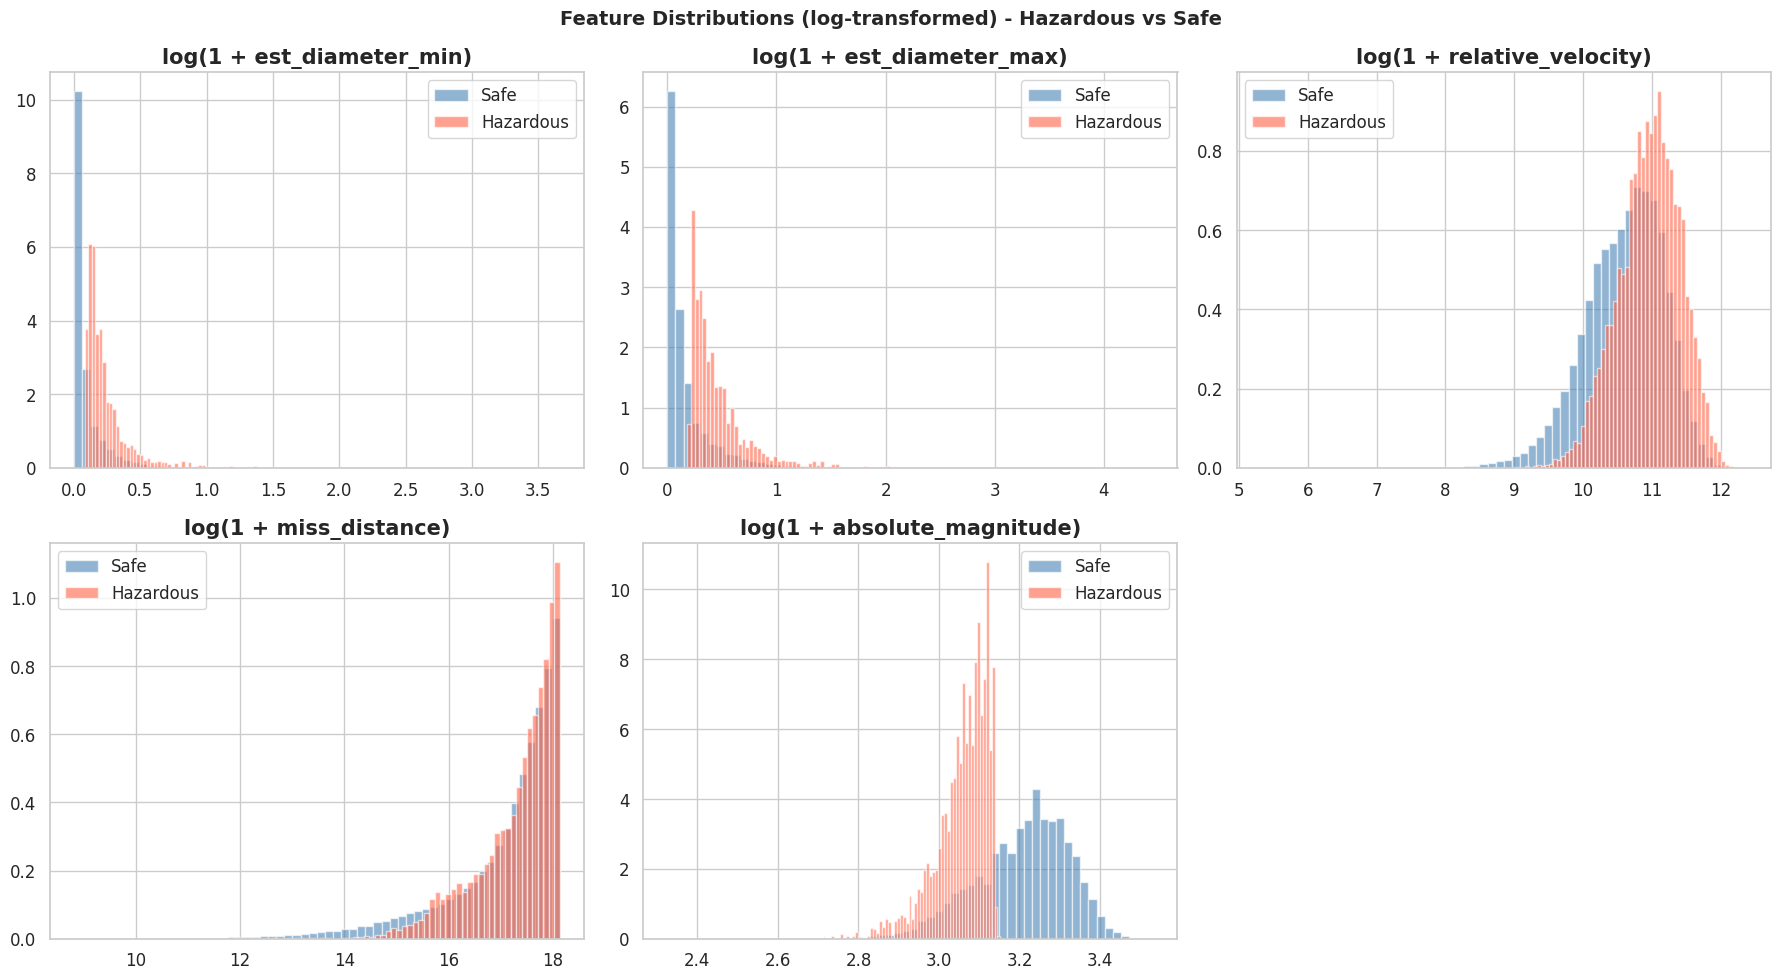

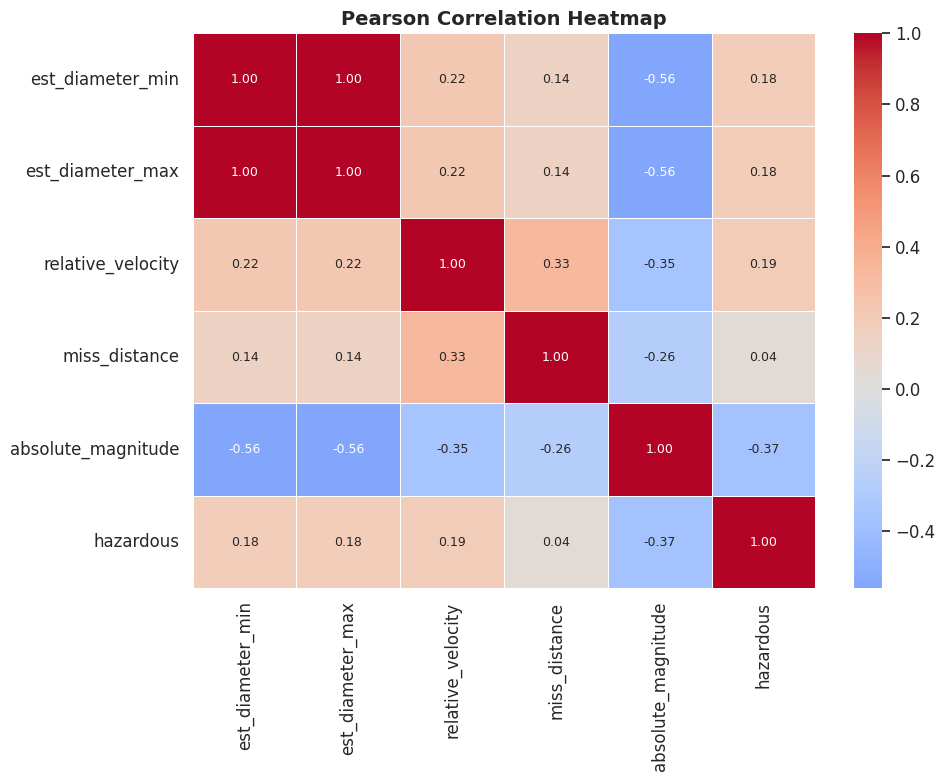

absolute_magnitude   -0.3653
miss_distance         0.0423
est_diameter_min      0.1834
est_diameter_max      0.1834
relative_velocity     0.1912
hazardous             1.0000
Name: hazardous, dtype: float64

In [67]:
features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    safe_vals = df_clean.loc[~df_clean["hazardous"], col]
    haz_vals = df_clean.loc[df_clean["hazardous"], col]
    axes[i].hist(np.log1p(safe_vals), bins=60, alpha=0.6, label="Safe", color="steelblue", density=True)
    axes[i].hist(np.log1p(haz_vals), bins=60, alpha=0.6, label="Hazardous", color="tomato", density=True)
    axes[i].set_title(f"log(1 + {col})", fontweight="bold")
    axes[i].legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle("Feature Distributions (log-transformed) - Hazardous vs Safe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_corr = df_clean.copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr["hazardous"].sort_values()

## 4. Feature Engineering

X shape: (90836, 6)
y counts:
hazardous
0    81996
1     8840
Name: count, dtype: int64


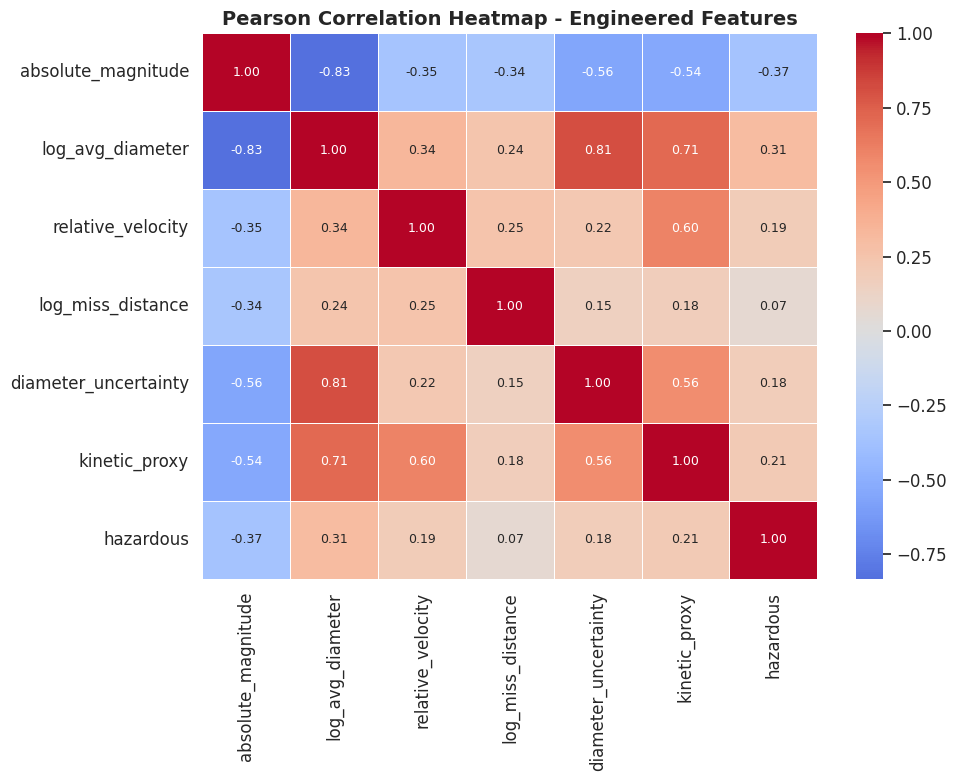

absolute_magnitude     -0.3653
log_miss_distance       0.0651
diameter_uncertainty    0.1834
relative_velocity       0.1912
kinetic_proxy           0.2098
log_avg_diameter        0.3107
hazardous               1.0000
Name: hazardous, dtype: float64

In [68]:
df_features = df_clean.copy()

df_features["avg_diameter"] = (df_features["est_diameter_min"] + df_features["est_diameter_max"]) / 2
df_features["diameter_uncertainty"] = df_features["est_diameter_max"] - df_features["est_diameter_min"]
df_features["log_avg_diameter"] = np.log1p(df_features["avg_diameter"])
df_features["log_miss_distance"] = np.log1p(df_features["miss_distance"])
df_features["kinetic_proxy"] = df_features["log_avg_diameter"] * df_features["relative_velocity"] * df_features["relative_velocity"]

FEATURES = [
    "absolute_magnitude",
    "log_avg_diameter",
    "relative_velocity",
    "log_miss_distance",
    "diameter_uncertainty",
    "kinetic_proxy",
]
TARGET = "hazardous"

X = df_features[FEATURES].copy()
y = df_features[TARGET].astype(int)

print(f"X shape: {X.shape}")
print("y counts:")
print(y.value_counts())

feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

df_corr = df_features[FEATURES + [TARGET]].copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title("Pearson Correlation Heatmap - Engineered Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr["hazardous"].sort_values()

## 5. Train, Validation, and Test Split

In [69]:
# Split the natural dataset first. Any class balancing is applied only to the
# QNN training subset later; validation and test remain untouched and realistic.
X_np = X.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.int64)

# 70 / 15 / 15 stratified split using sklearn.
X_tr_np, X_tmp_np, y_tr_np, y_tmp_np = train_test_split(
    X_np, y_np, test_size=0.30, random_state=SEED, stratify=y_np
)
X_val_np, X_te_np, y_val_np, y_te_np = train_test_split(
    X_tmp_np, y_tmp_np, test_size=0.50, random_state=SEED, stratify=y_tmp_np
)

print(f"Train size:      {len(X_tr_np):,}")
print(f"Validation size: {len(X_val_np):,}")
print(f"Test size:       {len(X_te_np):,}")
print(f"Train hazardous:      {int(y_tr_np.sum()):,} / {len(y_tr_np):,} ({y_tr_np.mean() * 100:.1f}%)")
print(f"Validation hazardous: {int(y_val_np.sum()):,} / {len(y_val_np):,} ({y_val_np.mean() * 100:.1f}%)")
print(f"Test hazardous:       {int(y_te_np.sum()):,} / {len(y_te_np):,} ({y_te_np.mean() * 100:.1f}%)")

# Keep the class weight tied to the natural training distribution regardless
# of the QNN runtime subset sampling mode.
train_pos_weight_value = float((y_tr_np == 0).sum() / max((y_tr_np == 1).sum(), 1))
print(f"Positive-class loss weight from natural train split: {train_pos_weight_value:.2f}")

Train size:      63,585
Validation size: 13,625
Test size:       13,626
Train hazardous:      6,188 / 63,585 (9.7%)
Validation hazardous: 1,326 / 13,625 (9.7%)
Test hazardous:       1,326 / 13,626 (9.7%)
Positive-class loss weight from natural train split: 9.28


## 6. Torch Preprocessing for the QNN

Set `USE_PCA = True` to standardize, project to 4 PCA components, and run the QNN with **4 qubits** (one rotation per component). Set `USE_PCA = False` to skip PCA entirely: every standardized engineered feature is passed in directly and the QNN uses **`n_qubits = len(FEATURES)`** (one qubit per feature). In both cases the values are min-max scaled into `[-pi/2, pi/2]` using training-set extrema.

In [70]:
# Toggle PCA preprocessing for the QNN.
#   USE_PCA=True  -> standardize -> PCA(4) -> min-max into [-pi/2, pi/2], n_qubits=4.
#   USE_PCA=False -> standardize ->          min-max into [-pi/2, pi/2], n_qubits=len(FEATURES).
USE_PCA = False
PCA_COMPONENTS = 4
RESCALE_RANGE = np.pi / 2

# 1. Standardize using training-set statistics only.
scaler_std = StandardScaler().fit(X_tr_np)
X_tr_std = scaler_std.transform(X_tr_np)
X_val_std = scaler_std.transform(X_val_np)
X_te_std = scaler_std.transform(X_te_np)

# 2. Optional PCA dimensionality reduction.
if USE_PCA:
    n_qubits = PCA_COMPONENTS
    pca = PCA(n_components=n_qubits, random_state=SEED).fit(X_tr_std)
    X_tr_red = pca.transform(X_tr_std)
    X_val_red = pca.transform(X_val_std)
    X_te_red = pca.transform(X_te_std)
    pca_summary = pd.DataFrame(
        {
            "component": [f"PC{i}" for i in range(1, n_qubits + 1)],
            "explained_variance": pca.explained_variance_ratio_,
            "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
        }
    )
else:
    n_qubits = X_tr_std.shape[1]
    X_tr_red, X_val_red, X_te_red = X_tr_std, X_val_std, X_te_std
    pca_summary = pd.DataFrame({"note": [f"PCA disabled; using all {n_qubits} standardized features"]})

# 3. Min-max scale each component into [-pi/2, pi/2] for angle encoding.
angle_scaler = MinMaxScaler(feature_range=(-RESCALE_RANGE, RESCALE_RANGE)).fit(X_tr_red)
X_tr_ang = angle_scaler.transform(X_tr_red).astype(np.float32)
X_val_ang = angle_scaler.transform(X_val_red).astype(np.float32)
X_te_ang = angle_scaler.transform(X_te_red).astype(np.float32)

# 4. Move to torch tensors on the QNN device.
X_tr_quantum = torch.from_numpy(X_tr_ang).to(torch_device)
X_val_quantum = torch.from_numpy(X_val_ang).to(torch_device)
X_te_quantum = torch.from_numpy(X_te_ang).to(torch_device)

y_tr_tensor = torch.from_numpy(y_tr_np.astype(np.float32)).reshape(-1, 1).to(torch_device)
y_val_tensor = torch.from_numpy(y_val_np.astype(np.float32)).reshape(-1, 1).to(torch_device)
y_te_tensor = torch.from_numpy(y_te_np.astype(np.float32)).reshape(-1, 1).to(torch_device)

print(f"USE_PCA = {USE_PCA}")
print(f"Original engineered features: {X_tr_np.shape[1]}")
print(f"Quantum input features (n_qubits): {X_tr_quantum.shape[1]}")
if USE_PCA:
    print(f"Total PCA variance retained: {pca.explained_variance_ratio_.sum():.3f}")
pca_summary

USE_PCA = False
Original engineered features: 6
Quantum input features (n_qubits): 6


,note
0,PCA disabled; using all 6 standardized features


## 7. Quantum Runtime Subsets

Quantum simulation dominates runtime even with PennyLane batch broadcasting, so the QNN uses configurable subsets. In the current configuration (`BALANCE_QNN_TRAIN_SUBSET = False`), train, validation, and test subsets are sampled from their natural stratified splits; optional training-only class balancing is available via the toggle.

In [71]:
# Requested maximum sizes for the QNN runtime subsets.
# If a requested size exceeds a split, stratified_sample returns all available
# examples for the over-requested class, so the actual subset can be smaller.
QNN_TRAIN_SAMPLES = 50000
QNN_VAL_SAMPLES = 12096
QNN_TEST_SAMPLES = 12096
USE_ALL = True  # Override to use all available samples regardless of the above requested sizes.
BALANCE_QNN_TRAIN_SUBSET = False


def take_class_indices(y_flat, label, n_take, generator, device):
    indices = torch.where(y_flat == label)[0]
    indices = indices[torch.randperm(indices.numel(), generator=generator, device=device)]
    return indices[:n_take]


def apply_sample_indices(X_tensor, y_tensor, indices, generator):
    indices = indices[torch.randperm(indices.numel(), generator=generator, device=X_tensor.device)]
    return X_tensor[indices], y_tensor[indices]


def stratified_sample(X_tensor, y_tensor, n_samples, seed):
    generator = torch.Generator(device=X_tensor.device)
    generator.manual_seed(seed)
    y_flat = y_tensor.flatten().long()
    n_pos = round(n_samples * y_flat.float().mean().item())
    n_neg = n_samples - n_pos

    indices = torch.cat([
        take_class_indices(y_flat, 0, n_neg, generator, X_tensor.device),
        take_class_indices(y_flat, 1, n_pos, generator, X_tensor.device),
    ])
    return apply_sample_indices(X_tensor, y_tensor, indices, generator)


def class_balanced_sample(X_tensor, y_tensor, n_samples, seed):
    generator = torch.Generator(device=X_tensor.device)
    generator.manual_seed(seed)
    y_flat = y_tensor.flatten().long()
    n_per_class = min(
        n_samples // 2,
        int((y_flat == 0).sum().item()),
        int((y_flat == 1).sum().item()),
    )
    if n_per_class == 0:
        raise ValueError("Both classes are required for a balanced QNN training subset.")

    indices = torch.cat([
        take_class_indices(y_flat, 0, n_per_class, generator, X_tensor.device),
        take_class_indices(y_flat, 1, n_per_class, generator, X_tensor.device),
    ])
    return apply_sample_indices(X_tensor, y_tensor, indices, generator)


if USE_ALL:
    X_tr_qnn, y_tr_qnn = X_tr_quantum, y_tr_tensor
    X_val_qnn, y_val_qnn = X_val_quantum, y_val_tensor
    X_te_qnn, y_te_qnn = X_te_quantum, y_te_tensor
elif BALANCE_QNN_TRAIN_SUBSET:
    X_tr_qnn, y_tr_qnn = class_balanced_sample(X_tr_quantum, y_tr_tensor, QNN_TRAIN_SAMPLES, SEED)
    X_val_qnn, y_val_qnn = stratified_sample(X_val_quantum, y_val_tensor, QNN_VAL_SAMPLES, SEED + 1)
    X_te_qnn, y_te_qnn = stratified_sample(X_te_quantum, y_te_tensor, QNN_TEST_SAMPLES, SEED + 2)
else:
    X_tr_qnn, y_tr_qnn = stratified_sample(X_tr_quantum, y_tr_tensor, QNN_TRAIN_SAMPLES, SEED)
    X_val_qnn, y_val_qnn = stratified_sample(X_val_quantum, y_val_tensor, QNN_VAL_SAMPLES, SEED + 1)
    X_te_qnn, y_te_qnn = stratified_sample(X_te_quantum, y_te_tensor, QNN_TEST_SAMPLES, SEED + 2)

print(f"USE_ALL = {USE_ALL}")
print(f"BALANCE_QNN_TRAIN_SUBSET = {BALANCE_QNN_TRAIN_SUBSET}")
pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [len(y_tr_qnn), len(y_val_qnn), len(y_te_qnn)],
        "hazardous": [int(y_tr_qnn.sum().item()), int(y_val_qnn.sum().item()), int(y_te_qnn.sum().item())],
        "hazardous_%": [
            y_tr_qnn.mean().item() * 100,
            y_val_qnn.mean().item() * 100,
            y_te_qnn.mean().item() * 100,
        ],
    }
)


USE_ALL = True
BALANCE_QNN_TRAIN_SUBSET = False


,split,samples,hazardous,hazardous_%
0,train,63585,6188,9.7319
1,validation,13625,1326,9.7321
2,test,13626,1326,9.7314


## 8. Quantum Circuit Architecture

This cell defines the complete QNN architecture in one place: PennyLane device, IQP feature map, feature-reuploading loop, variational ansatz, QNode readout, and the Torch wrapper. Each reupload block receives its own slice of `theta` with shape `(ANSATZ_LAYERS, n_qubits, 3)`.


In [72]:
readout_wire = 0
qml_device_name = "default.qubit"
qnode_diff_method = "backprop"

FEATURE_REUPLOADS = [1, 2, 3, 4]
IQP_N_REPEATS = 1
ANSATZ_LAYERS = 2

reupload_depths = [FEATURE_REUPLOADS] if isinstance(FEATURE_REUPLOADS, int) else list(FEATURE_REUPLOADS)
dev = qml.device(qml_device_name, wires=n_qubits, shots=None)


def theta_shape(reuploads):
    # One independent StronglyEntanglingLayers weight tensor per feature reupload.
    return (reuploads, ANSATZ_LAYERS, n_qubits, 3)


@qml.qnode(dev, interface="torch", diff_method=qnode_diff_method)
def qnn_circuit(feature_angles, theta):
    for theta_block in theta:
        qml.IQPEmbedding(
            features=feature_angles,
            wires=range(n_qubits),
            n_repeats=IQP_N_REPEATS,
        )
        qml.StronglyEntanglingLayers(weights=theta_block, wires=range(n_qubits))

    # Read out <Z_w> on every wire. Returned as a tuple of length n_qubits;
    # under broadcasting each entry has shape (batch,).
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]


class QuantumHazardClassifier(nn.Module):
    """Quantum circuit + tiny linear readout that maps n_qubits expectation
    values to a single binary logit. The only trainable parameters are the
    ansatz angles `theta` plus a Linear(n_qubits, 1) head (n_qubits + 1 scalars).
    """

    def __init__(self, reuploads, init_scale=0.05):
        super().__init__()
        self.reuploads = reuploads
        self.theta = nn.Parameter(torch.randn(theta_shape(reuploads), dtype=torch.float32, device=torch_device) * init_scale)
        self.readout = nn.Linear(n_qubits, 1).to(torch_device)

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)

        x = x.to(device=torch_device, dtype=torch.float32)
        expectations = qnn_circuit(x, self.theta)
        # qnn_circuit returns a list/tuple of per-wire expectations. Stack into
        # shape (batch, n_qubits) so the linear head can combine them.
        z = torch.stack(list(expectations), dim=-1).float()
        if z.ndim == 1:
            z = z.unsqueeze(0)
        logit = self.readout(z)
        return logit.reshape(-1, 1).float()


print(f"PennyLane device: {qml_device_name}, diff_method={qnode_diff_method}, interface=torch")
print(f"Feature map: qml.IQPEmbedding(n_repeats={IQP_N_REPEATS})")
print(f"Ansatz: qml.StronglyEntanglingLayers(layers={ANSATZ_LAYERS})")

for depth in reupload_depths:
    print(f"N={depth}: theta_shape={theta_shape(depth)}, quantum_parameters={np.prod(theta_shape(depth))}")

probe_model = QuantumHazardClassifier(reuploads=reupload_depths[0]).to(torch_device)
x_probe = X_tr_qnn[:4]

with torch.no_grad():
    probe_logits = probe_model(x_probe)
    probe_proba = torch.sigmoid(probe_logits)

print(probe_model)
print(f"Probe batch shape: {tuple(x_probe.shape)}")
print(f"Probe logit shape: {tuple(probe_logits.shape)}")
print(f"Probe logits:        {probe_logits.detach().cpu().numpy().round(3).ravel()}")
print(f"Probe probabilities: {probe_proba.detach().cpu().numpy().round(3).ravel()}")


PennyLane device: default.qubit, diff_method=backprop, interface=torch
Feature map: qml.IQPEmbedding(n_repeats=1)
Ansatz: qml.StronglyEntanglingLayers(layers=2)
N=1: theta_shape=(1, 2, 6, 3), quantum_parameters=36
N=2: theta_shape=(2, 2, 6, 3), quantum_parameters=72
N=3: theta_shape=(3, 2, 6, 3), quantum_parameters=108
N=4: theta_shape=(4, 2, 6, 3), quantum_parameters=144
QuantumHazardClassifier(
  (readout): Linear(in_features=6, out_features=1, bias=True)
)
Probe batch shape: (4, 6)
Probe logit shape: (4, 1)
Probe logits:        [-0.204 -0.194 -0.198 -0.196]
Probe probabilities: [0.449 0.452 0.451 0.451]


## 9. Training Setup and Metrics

Both models now return logits and are trained with `BCEWithLogitsLoss(pos_weight=...)`. The QNN logit is produced by a tiny `Linear(n_qubits, 1)` head over the per-wire Pauli-Z expectations; the classical MLP outputs its logit directly. The shared utility code below handles batched prediction, threshold tuning, metric evaluation, and confusion-matrix plotting.


In [73]:
batch_size = 512
eval_batch_size = 512

train_loader = DataLoader(
    TensorDataset(X_tr_qnn.to(torch_device), y_tr_qnn.to(torch_device)),
    batch_size=batch_size,
    shuffle=True,
)

pos_weight = torch.tensor([train_pos_weight_value], dtype=torch.float32, device=torch_device)
qnn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
classical_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def predict_batches(model, X_tensor, batch_size=eval_batch_size):
    model.eval()
    outputs = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            xb = X_tensor[start : start + batch_size].to(torch_device)
            outputs.append(model(xb).detach())

    return torch.cat(outputs, dim=0)



def evaluate_probabilities(y_tensor, y_proba, threshold=0.50):
    y_proba = y_proba.detach().flatten()
    y_true = y_tensor.detach().flatten().cpu().numpy().astype(int)
    y_score = y_proba.cpu().numpy()
    y_pred_np = (y_score >= threshold).astype(int)
    has_both_classes = len(np.unique(y_true)) == 2

    return {
        "metrics": {
            "accuracy": metrics.accuracy_score(y_true, y_pred_np),
            "precision": metrics.precision_score(y_true, y_pred_np, zero_division=0),
            "recall": metrics.recall_score(y_true, y_pred_np, zero_division=0),
            "f1": metrics.f1_score(y_true, y_pred_np, zero_division=0),
            "roc_auc": metrics.roc_auc_score(y_true, y_score) if has_both_classes else np.nan,
            "avg_precision": metrics.average_precision_score(y_true, y_score) if has_both_classes else np.nan,
        },
        "y_pred": torch.as_tensor(y_pred_np, dtype=torch.long, device=y_proba.device),
        "y_proba": y_proba,
    }


def tune_threshold(y_tensor, y_proba):
    y_true = y_tensor.detach().flatten().cpu().numpy().astype(int)
    y_score = y_proba.detach().flatten().cpu().numpy()
    rows = []

    for threshold in np.unique(y_score):
        y_pred = (y_score >= threshold).astype(int)
        rows.append(
            {
                "threshold": float(threshold),
                "precision": metrics.precision_score(y_true, y_pred, zero_division=0),
                "recall": metrics.recall_score(y_true, y_pred, zero_division=0),
                "f1": metrics.f1_score(y_true, y_pred, zero_division=0),
            }
        )

    curve = pd.DataFrame(rows)
    best_idx = curve["f1"].idxmax()
    return float(curve.loc[best_idx, "threshold"]), curve


def plot_confusion_matrix(y_true, y_pred, title):
    y_true_np = y_true.detach().flatten().cpu().numpy().astype(int)
    y_pred_np = y_pred.detach().flatten().cpu().numpy().astype(int)
    cm = metrics.confusion_matrix(y_true_np, y_pred_np, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        cbar=False,
        xticklabels=["Safe", "Hazardous"],
        yticklabels=["Safe", "Hazardous"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


print(f"Batch size: {batch_size}")
print(f"Eval batch size: {eval_batch_size}")
print(f"Positive-class loss weight (natural train neg/pos): {pos_weight.item():.2f}")
print("QNN loss: BCEWithLogitsLoss on linear-readout logits over <Z_w>")
print("Classical MLP loss: BCEWithLogitsLoss on raw logits")


Batch size: 512
Eval batch size: 512
Positive-class loss weight (natural train neg/pos): 9.28
QNN loss: BCEWithLogitsLoss on linear-readout logits over <Z_w>
Classical MLP loss: BCEWithLogitsLoss on raw logits


## 10. Train QNNs

Each requested reupload depth is trained once, then evaluated with a validation-tuned threshold.

In [74]:
# Print the QNode circuit for each requested reupload depth before training.
import torch as _torch

_dummy_x = X_tr_qnn[:1].detach()  # shape (1, n_qubits)

for _depth in reupload_depths:
    _theta_dummy = _torch.zeros(theta_shape(_depth))
    _drawer = qml.draw(qnn_circuit, max_length=140, decimals=2)
    print(f"\n=== Circuit for FEATURE_REUPLOADS = {_depth}, ANSATZ_LAYERS = {ANSATZ_LAYERS} ===")
    print(_drawer(_dummy_x[0], _theta_dummy))
    _specs = qml.specs(qnn_circuit)(_dummy_x[0], _theta_dummy)
    print(f"gate counts: {_specs['resources'].gate_types}")
    print(f"depth: {_specs['resources'].depth}, total gates: {_specs['resources'].num_gates}")


=== Circuit for FEATURE_REUPLOADS = 1, ANSATZ_LAYERS = 2 ===
0: ─╭IQPEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
4: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
5: ─╰IQPEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
tensor([ 0.5092, -1.5409, -1.2819,  1.4437, -1.5687, -1.5694], device='cuda:0')
M1 = 
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
gate counts: {'IQPEmbedding': 1, 'StronglyEntanglingLayers': 1}
depth: 2, total gates: 2

=== Circuit for FEATURE_REUPLOADS = 2, ANSATZ_LAYERS = 2 ===
0: ─╭IQPEmbedding(M0)─╭StronglyEntanglingLayers(M1)─╭IQPEmbe

In [75]:
max_epochs = 350
qnn_learning_rate = 0.002


def train_qnn(reuploads):
    torch.manual_seed(SEED + 100 * reuploads)

    model = QuantumHazardClassifier(reuploads).to(torch_device)
    optimizer = torch.optim.Adam(model.parameters(), lr=qnn_learning_rate)
    history = []

    print()
    print(f"Training QNN with N={reuploads} feature reupload(s)")
    print(f"Trainable quantum parameters: {model.theta.numel()}")

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = qnn_criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(xb)

        train_loss /= len(train_loader.dataset)
        val_logits = predict_batches(model, X_val_qnn)
        val_targets = y_val_qnn.to(val_logits.device).reshape(-1, 1)
        val_loss = qnn_criterion(val_logits, val_targets).item()
        val_proba = torch.sigmoid(val_logits).flatten()
        val_metrics = evaluate_probabilities(y_val_qnn, val_proba, threshold=0.50)["metrics"]

        row = {
            "reuploads": reuploads,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_avg_precision": val_metrics["avg_precision"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_f1": val_metrics["f1"],
        }
        history.append(row)

        print(
            f"[N={reuploads}] Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_avg_precision={row['val_avg_precision']:.4f} | "
            f"val_f1={row['val_f1']:.4f}"
        )

    val_proba = torch.sigmoid(predict_batches(model, X_val_qnn)).flatten()
    threshold, threshold_curve = tune_threshold(y_val_qnn, val_proba)
    validation = evaluate_probabilities(y_val_qnn, val_proba, threshold)

    test_proba = torch.sigmoid(predict_batches(model, X_te_qnn)).flatten()
    test = evaluate_probabilities(y_te_qnn, test_proba, threshold)
    history_df = pd.DataFrame(history)

    summary = {
        "reuploads": reuploads,
        "quantum_parameters": model.theta.numel(),
        "total_trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "val_loss": history_df["val_loss"].iloc[-1],
        "threshold": threshold,
    }
    summary.update({f"val_{name}": value for name, value in validation["metrics"].items()})
    summary.update({f"test_{name}": value for name, value in test["metrics"].items()})

    return {
        "reuploads": reuploads,
        "model": model,
        "history": history_df,
        "threshold": threshold,
        "threshold_curve": threshold_curve,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "validation": validation,
        "test": test,
        "summary": summary,
    }


experiment_results = [train_qnn(depth) for depth in reupload_depths]
comparison_df = pd.DataFrame([result["summary"] for result in experiment_results]).set_index("reuploads")



Training QNN with N=1 feature reupload(s)
Trainable quantum parameters: 36
[N=1] Epoch 01 | train_loss=1.2494 | val_loss=1.2102 | val_avg_precision=0.2535 | val_f1=0.2957
[N=1] Epoch 02 | train_loss=1.1452 | val_loss=1.0716 | val_avg_precision=0.2602 | val_f1=0.3914
[N=1] Epoch 03 | train_loss=1.0136 | val_loss=0.9669 | val_avg_precision=0.2624 | val_f1=0.4084
[N=1] Epoch 04 | train_loss=0.9313 | val_loss=0.8958 | val_avg_precision=0.2641 | val_f1=0.4119
[N=1] Epoch 05 | train_loss=0.8610 | val_loss=0.8282 | val_avg_precision=0.2682 | val_f1=0.4234
[N=1] Epoch 06 | train_loss=0.8083 | val_loss=0.7930 | val_avg_precision=0.2708 | val_f1=0.4264
[N=1] Epoch 07 | train_loss=0.7817 | val_loss=0.7735 | val_avg_precision=0.2733 | val_f1=0.4304
[N=1] Epoch 08 | train_loss=0.7648 | val_loss=0.7587 | val_avg_precision=0.2780 | val_f1=0.4323
[N=1] Epoch 09 | train_loss=0.7518 | val_loss=0.7468 | val_avg_precision=0.2821 | val_f1=0.4334
[N=1] Epoch 10 | train_loss=0.7421 | val_loss=0.7381 | val_a

In [76]:
best_result = max(
    experiment_results,
    key=lambda result: (result["summary"]["val_f1"], result["summary"]["val_avg_precision"]),
)

model = best_result["model"]
best_threshold = best_result["threshold"]

print()
print(f"Selected N={best_result['reuploads']} by test F1 with threshold={best_threshold:.3f}.")
comparison_df.round(4)


Selected N=4 by test F1 with threshold=0.664.


,quantum_parameters,total_trainable_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
reuploads,,,,,,,,,,,,,,,,
1,36,43,0.5863,0.6506,0.8111,0.3285,0.9012,0.4815,0.9034,0.4460,0.8068,0.3218,0.8891,0.4725,0.8995,0.4432
2,72,79,0.5709,0.5877,0.7968,0.3185,0.9540,0.4775,0.9039,0.4671,0.7914,0.3131,0.9578,0.4719,0.9021,0.4498
3,108,115,0.5614,0.6887,0.8094,0.3276,0.9110,0.4819,0.9059,0.4764,0.8059,0.3221,0.9005,0.4745,0.9033,0.4623
4,144,151,0.5527,0.6636,0.8099,0.3311,0.9344,0.4890,0.9069,0.4806,0.8032,0.3216,0.9216,0.4768,0.9025,0.4615


In [77]:
## ENTANGLEMENT DIAGNOSTIC

# 1) Template counts in the full QNode (sanity check that the expected
#    embedding and ansatz blocks are present).
specs = qml.specs(qnn_circuit)(X_tr_qnn[:1], best_result["model"].theta.detach())
print("Full circuit gate counts (per call):")
print(specs["resources"].gate_types)

# 2) Single-wire reduced-state purity. purity = Tr(rho_w^2).
#    1.0 -> wire is in a pure state (no entanglement with the rest).
#    <1  -> wire is entangled with the rest of the register.
@qml.qnode(dev, interface="torch", diff_method=None)
def reduced_dm_full(feature_angles, theta, w):
    for theta_block in theta:
        qml.IQPEmbedding(
            features=feature_angles,
            wires=range(n_qubits),
            n_repeats=IQP_N_REPEATS,
        )
        qml.StronglyEntanglingLayers(weights=theta_block, wires=range(n_qubits))

    return qml.density_matrix(wires=[w])


# No-entanglement ablation: keep local feature and ansatz rotations, remove
# the IQP MultiRZ couplings and StronglyEntanglingLayers CNOT pattern.
@qml.qnode(dev, interface="torch", diff_method=None)
def qnn_circuit_no_ent(feature_angles, theta):
    for theta_block in theta:
        for wire in range(n_qubits):
            qml.Hadamard(wires=wire)
        for _ in range(IQP_N_REPEATS):
            for wire in range(n_qubits):
                qml.RZ(feature_angles[..., wire], wires=wire)
        for layer in range(theta_block.shape[0]):
            for wire in range(n_qubits):
                qml.Rot(
                    theta_block[layer, wire, 0],
                    theta_block[layer, wire, 1],
                    theta_block[layer, wire, 2],
                    wires=wire,
                )

    return qml.expval(qml.PauliZ(readout_wire))


@qml.qnode(dev, interface="torch", diff_method=None)
def reduced_dm_no_ent(feature_angles, theta, w):
    for theta_block in theta:
        for wire in range(n_qubits):
            qml.Hadamard(wires=wire)
        for _ in range(IQP_N_REPEATS):
            for wire in range(n_qubits):
                qml.RZ(feature_angles[..., wire], wires=wire)
        for layer in range(theta_block.shape[0]):
            for wire in range(n_qubits):
                qml.Rot(
                    theta_block[layer, wire, 0],
                    theta_block[layer, wire, 1],
                    theta_block[layer, wire, 2],
                    wires=wire,
                )

    return qml.density_matrix(wires=[w])


theta_eval = best_result["model"].theta.detach()
samples = X_tr_qnn[:8]

rows = []
for s_idx, x in enumerate(samples):
    z_full_all = qnn_circuit(x, theta_eval)
    z_full = float(z_full_all[readout_wire])
    z_noent = qnn_circuit_no_ent(x, theta_eval).item()
    purities_full = []
    purities_noent = []
    for w in range(n_qubits):
        rho_f = reduced_dm_full(x, theta_eval, w)
        rho_n = reduced_dm_no_ent(x, theta_eval, w)
        purities_full.append(torch.trace(rho_f @ rho_f).real.item())
        purities_noent.append(torch.trace(rho_n @ rho_n).real.item())
    rows.append({
        "sample": s_idx,
        "Z0_full": z_full,
        "Z0_no_ent": z_noent,
        "delta_Z0": z_full - z_noent,
        **{f"purity_w{w}_full": purities_full[w] for w in range(n_qubits)},
        **{f"purity_w{w}_no_ent": purities_noent[w] for w in range(n_qubits)},
    })

diag_df = pd.DataFrame(rows)
print()
print("Readout and purity per sample:")
print(diag_df.round(4).to_string(index=False))

print()
print("Mean |Z0_full - Z0_no_ent|:", diag_df["delta_Z0"].abs().mean().round(4))
print("Mean purity (full circuit), per wire:")
print(diag_df[[f"purity_w{w}_full" for w in range(n_qubits)]].mean().round(4))
print("Mean purity (ablated, no entangling gates), per wire:")
print(diag_df[[f"purity_w{w}_no_ent" for w in range(n_qubits)]].mean().round(4))


Full circuit gate counts (per call):
{'IQPEmbedding': 4, 'StronglyEntanglingLayers': 4}

Readout and purity per sample:
 sample  Z0_full  Z0_no_ent  delta_Z0  purity_w0_full  purity_w1_full  purity_w2_full  purity_w3_full  purity_w4_full  purity_w5_full  purity_w0_no_ent  purity_w1_no_ent  purity_w2_no_ent  purity_w3_no_ent  purity_w4_no_ent  purity_w5_no_ent
      0   0.1214    -0.9747    1.0961          0.5080          0.5284          0.5220          0.5218          0.5048          0.5647            1.0000            1.0000            1.0000            1.0000            1.0000            1.0000
      1   0.1229    -0.8320    0.9548          0.5147          0.5415          0.5238          0.5434          0.5922          0.5630            1.0000            1.0000            1.0000            1.0000            1.0000            1.0000
      2   0.2933    -0.9285    1.2219          0.5466          0.5590          0.5691          0.5317          0.5390          0.5729            1.0000   

## 11. Training Curves and Depth Comparison


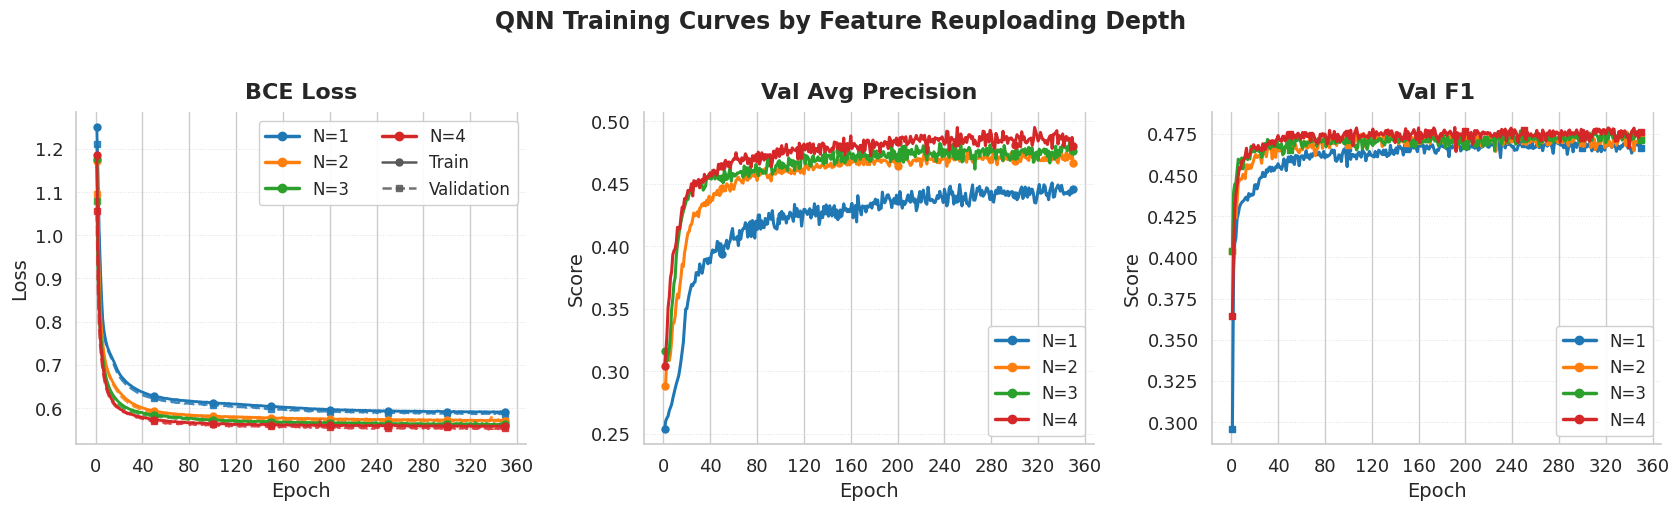

,quantum_parameters,total_trainable_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
reuploads,,,,,,,,,,,,,,,,
1,36,43,0.5863,0.6506,0.8111,0.3285,0.9012,0.4815,0.9034,0.4460,0.8068,0.3218,0.8891,0.4725,0.8995,0.4432
2,72,79,0.5709,0.5877,0.7968,0.3185,0.9540,0.4775,0.9039,0.4671,0.7914,0.3131,0.9578,0.4719,0.9021,0.4498
3,108,115,0.5614,0.6887,0.8094,0.3276,0.9110,0.4819,0.9059,0.4764,0.8059,0.3221,0.9005,0.4745,0.9033,0.4623
4,144,151,0.5527,0.6636,0.8099,0.3311,0.9344,0.4890,0.9069,0.4806,0.8032,0.3216,0.9216,0.4768,0.9025,0.4615


In [85]:
from matplotlib.lines import Line2D

# --- Tunable: show a marker every PLOT_MARKER_EVERY epochs to avoid clutter ---
PLOT_MARKER_EVERY = 50

all_history_df = pd.concat([result["history"] for result in experiment_results], ignore_index=True)

palette = plt.cm.tab10.colors
depth_colors = {d: palette[i % len(palette)] for i, d in enumerate(sorted(all_history_df["reuploads"].unique()))}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Shared per-depth color legend
color_handles = [
    Line2D([0], [0], color=depth_colors[d], linewidth=2.5, marker="o", markersize=6, label=f"N={d}")
    for d in sorted(depth_colors)
]

# --- Panel 0: BCE Loss (train solid, val dashed) ---
for reuploads, group in all_history_df.groupby("reuploads"):
    c = depth_colors[reuploads]
    epochs = group["epoch"].to_numpy()
    mask = (epochs % PLOT_MARKER_EVERY == 0) | (epochs == epochs[0]) | (epochs == epochs[-1])
    # Continuous line (no markers)
    axes[0].plot(group["epoch"], group["train_loss"], color=c, linewidth=2.0)
    axes[0].plot(group["epoch"], group["val_loss"],   color=c, linewidth=2.0, linestyle="--", alpha=0.85)
    # Sparse markers only at selected epochs
    axes[0].plot(group["epoch"][mask], group["train_loss"][mask], color=c,
                 linestyle="none", marker="o", markersize=5)
    axes[0].plot(group["epoch"][mask], group["val_loss"][mask],   color=c,
                 linestyle="none", marker="s", markersize=5, alpha=0.85)
    axes[0].fill_between(group["epoch"], group["train_loss"], group["val_loss"], color=c, alpha=0.07)

style_loss = [
    Line2D([0], [0], color="0.35", linewidth=1.8, marker="o", markersize=5, label="Train"),
    Line2D([0], [0], color="0.35", linewidth=1.8, marker="s", markersize=5, linestyle="--", alpha=0.85, label="Validation"),
]
axes[0].legend(handles=color_handles + style_loss, fontsize=12, framealpha=0.92, ncol=2)
axes[0].set_title("BCE Loss", fontsize=16, fontweight="bold", pad=10)
axes[0].set_xlabel("Epoch", fontsize=14)
axes[0].set_ylabel("Loss", fontsize=14)

# --- Panel 1: Val Avg Precision ---
for reuploads, group in all_history_df.groupby("reuploads"):
    c = depth_colors[reuploads]
    epochs = group["epoch"].to_numpy()
    mask = (epochs % PLOT_MARKER_EVERY == 0) | (epochs == epochs[0]) | (epochs == epochs[-1])
    axes[1].plot(group["epoch"], group["val_avg_precision"], color=c, linewidth=2.2)
    axes[1].plot(group["epoch"][mask], group["val_avg_precision"][mask],
                 color=c, linestyle="none", marker="o", markersize=5)

axes[1].legend(handles=color_handles, fontsize=12, framealpha=0.92)
axes[1].set_title("Val Avg Precision", fontsize=16, fontweight="bold", pad=10)
axes[1].set_xlabel("Epoch", fontsize=14)
axes[1].set_ylabel("Score", fontsize=14)

# --- Panel 2: Val F1 ---
for reuploads, group in all_history_df.groupby("reuploads"):
    c = depth_colors[reuploads]
    epochs = group["epoch"].to_numpy()
    mask = (epochs % PLOT_MARKER_EVERY == 0) | (epochs == epochs[0]) | (epochs == epochs[-1])
    axes[2].plot(group["epoch"], group["val_f1"], color=c, linewidth=2.2)
    axes[2].plot(group["epoch"][mask], group["val_f1"][mask],
                 color=c, linestyle="none", marker="s", markersize=5)

axes[2].legend(handles=color_handles, fontsize=12, framealpha=0.92)
axes[2].set_title("Val F1", fontsize=16, fontweight="bold", pad=10)
axes[2].set_xlabel("Epoch", fontsize=14)
axes[2].set_ylabel("Score", fontsize=14)

# --- Shared styling ---
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6)
    ax.tick_params(labelsize=13)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.suptitle("QNN Training Curves by Feature Reuploading Depth", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

comparison_df.round(4)


## 12. Validation Threshold

The QNN now outputs a logit produced by a small `Linear(n_qubits, 1)` head over the per-wire ⟨Z_w⟩ expectations, and probabilities are obtained via `sigmoid`. The tuned threshold below maximizes validation F1.


Model: QNN N=4 (selected by val_f1)


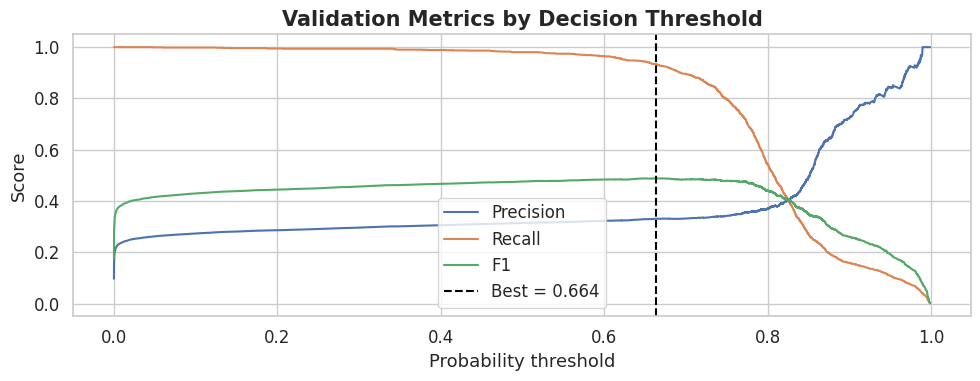

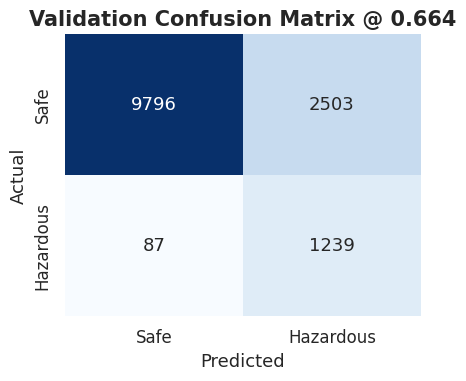

,accuracy,precision,recall,f1,roc_auc,avg_precision
threshold 0.50,0.7901,0.3145,0.9804,0.4762,0.9069,0.4806
threshold 0.664,0.8099,0.3311,0.9344,0.4890,0.9069,0.4806


In [79]:
threshold_curve = best_result["threshold_curve"]
baseline = evaluate_probabilities(y_val_qnn, best_result["val_proba"], threshold=0.50)
tuned = best_result["validation"]

print(f"Model: QNN N={best_result['reuploads']} (selected by val_f1)")

validation_metrics_df = pd.DataFrame(
    [baseline["metrics"], tuned["metrics"]],
    index=["threshold 0.50", f"threshold {best_threshold:.3f}"],
).round(4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(threshold_curve["threshold"], threshold_curve["precision"], label="Precision")
ax.plot(threshold_curve["threshold"], threshold_curve["recall"], label="Recall")
ax.plot(threshold_curve["threshold"], threshold_curve["f1"], label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Best = {best_threshold:.3f}")
ax.set_title("Validation Metrics by Decision Threshold", fontweight="bold")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

plot_confusion_matrix(y_val_qnn, tuned["y_pred"], f"Validation Confusion Matrix @ {best_threshold:.3f}")

validation_metrics_df


## 13. Held-Out Test Evaluation

Each requested depth is evaluated on the test split with its own validation-tuned threshold for comparison. The selected final model is still chosen by validation F1, not by test performance.

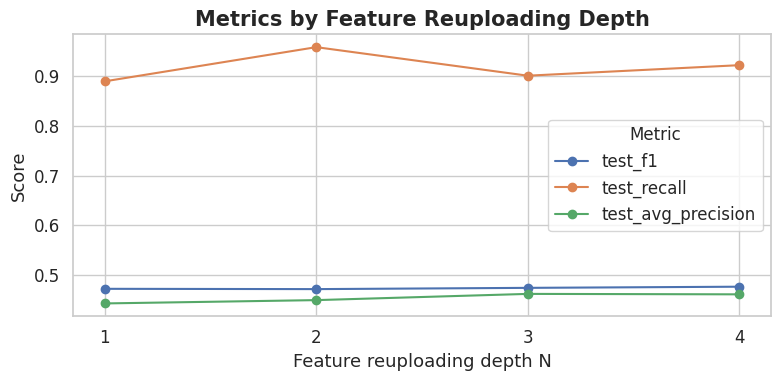

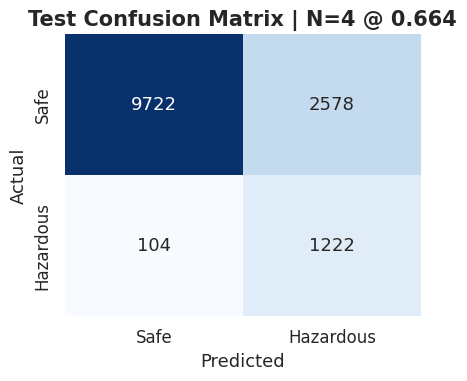

Selected feature reuploading depth N=4.


,quantum_parameters,total_trainable_parameters,val_loss,threshold,val_f1,val_roc_auc,val_avg_precision,test_f1,test_recall,test_avg_precision
reuploads,,,,,,,,,,
1,36,43,0.5863,0.6506,0.4815,0.9034,0.4460,0.4725,0.8891,0.4432
2,72,79,0.5709,0.5877,0.4775,0.9039,0.4671,0.4719,0.9578,0.4498
3,108,115,0.5614,0.6887,0.4819,0.9059,0.4764,0.4745,0.9005,0.4623
4,144,151,0.5527,0.6636,0.4890,0.9069,0.4806,0.4768,0.9216,0.4615


In [80]:
final_metrics_df = pd.DataFrame([result["summary"] for result in experiment_results]).set_index("reuploads")

metric_columns = [
    "quantum_parameters",
    "total_trainable_parameters",
    "val_loss",
    "threshold",
    "val_f1",
    "val_roc_auc",
    "val_avg_precision",
    "test_f1",
    "test_recall",
    "test_avg_precision",
]

fig, ax = plt.subplots(figsize=(8, 4))
final_metrics_df[["test_f1", "test_recall", "test_avg_precision"]].plot(marker="o", ax=ax)
ax.set_title("Metrics by Feature Reuploading Depth", fontweight="bold")
ax.set_xlabel("Feature reuploading depth N")
ax.set_ylabel("Score")
ax.set_xticks(final_metrics_df.index)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

plot_confusion_matrix(
    y_te_qnn,
    best_result["test"]["y_pred"],
    f"Test Confusion Matrix | N={best_result['reuploads']} @ {best_threshold:.3f}",
)

print(f"Selected feature reuploading depth N={best_result['reuploads']}.")
final_metrics_df[metric_columns].round(4)


## 14. Classical Torch Baseline

The classical baseline below uses the exact same QNN runtime tensors: `X_tr_qnn`, `y_tr_qnn`, `X_val_qnn`, `y_val_qnn`, `X_te_qnn`, and `y_te_qnn`. Only the model architecture changes.


Training classical Torch MLP on the same QNN tensors
Train samples: 63,585; validation samples: 13,625; test samples: 13,626
Architecture: Linear(6, 4) -> Linear(4, 8) -> Linear(8, 1)
Trainable classical parameters: 77
[Classical MLP] Epoch 01 | train_loss=1.2397 | val_loss=1.2159 | val_avg_precision=0.2517 | val_roc_auc=0.8191
[Classical MLP] Epoch 02 | train_loss=1.1618 | val_loss=1.1059 | val_avg_precision=0.2585 | val_roc_auc=0.8326
[Classical MLP] Epoch 03 | train_loss=1.0525 | val_loss=0.9950 | val_avg_precision=0.2697 | val_roc_auc=0.8464
[Classical MLP] Epoch 04 | train_loss=0.9414 | val_loss=0.8894 | val_avg_precision=0.2794 | val_roc_auc=0.8567
[Classical MLP] Epoch 05 | train_loss=0.8515 | val_loss=0.8125 | val_avg_precision=0.2890 | val_roc_auc=0.8651
[Classical MLP] Epoch 06 | train_loss=0.7841 | val_loss=0.7558 | val_avg_precision=0.2964 | val_roc_auc=0.8708
[Classical MLP] Epoch 07 | train_loss=0.7354 | val_loss=0.7136 | val_avg_precision=0.2969 | val_roc_auc=0.8723
[Cl

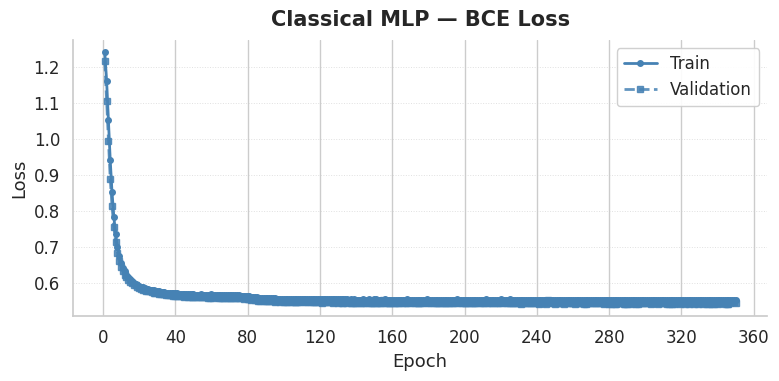

,architecture,trainable_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
0,Classical MLP,77,0.5450,0.7127,0.8162,0.3326,0.8824,0.4831,0.9117,0.5066,0.8109,0.3257,0.8808,0.4756,0.9092,0.4936


In [81]:
CLASSICAL_EPOCHS = max_epochs
CLASSICAL_LEARNING_RATE = 1e-3
CLASSICAL_HIDDEN_DIMS = (4, 8)  # three Linear layers total: input->16->8->logit


class ClassicalHazardClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(16, 8)):
        super().__init__()
        dims = [input_dim, *hidden_dims, 1]
        layers = []

        for in_features, out_features in zip(dims[:-2], dims[1:-1]):
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)

        x = x.to(device=torch_device, dtype=torch.float32)
        return self.net(x)


# Same tensors as the QNN training loader.
assert torch.equal(train_loader.dataset.tensors[0], X_tr_qnn)
assert torch.equal(train_loader.dataset.tensors[1], y_tr_qnn)

torch.manual_seed(SEED + 9000)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 9000)

classical_model = ClassicalHazardClassifier(input_dim=n_qubits, hidden_dims=CLASSICAL_HIDDEN_DIMS).to(torch_device)
classical_optimizer = torch.optim.Adam(classical_model.parameters(), lr=CLASSICAL_LEARNING_RATE)
classical_history = []
classical_parameter_count = sum(param.numel() for param in classical_model.parameters() if param.requires_grad)
classical_linear_layers = [layer for layer in classical_model.net if isinstance(layer, nn.Linear)]
classical_architecture = " -> ".join(
    f"Linear({layer.in_features}, {layer.out_features})" for layer in classical_linear_layers
)

print()
print("Training classical Torch MLP on the same QNN tensors")
print(f"Train samples: {len(y_tr_qnn):,}; validation samples: {len(y_val_qnn):,}; test samples: {len(y_te_qnn):,}")
print(f"Architecture: {classical_architecture}")
print(f"Trainable classical parameters: {classical_parameter_count}")

for epoch in range(1, CLASSICAL_EPOCHS + 1):
    classical_model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        classical_optimizer.zero_grad()
        logits = classical_model(xb)
        loss = classical_criterion(logits, yb)
        loss.backward()
        classical_optimizer.step()

        train_loss += loss.item() * len(xb)

    train_loss /= len(train_loader.dataset)
    val_logits = predict_batches(classical_model, X_val_qnn)
    val_loss = classical_criterion(val_logits, y_val_qnn.to(val_logits.device)).item()
    val_proba = torch.sigmoid(val_logits).flatten()
    val_metrics = evaluate_probabilities(y_val_qnn, val_proba, threshold=0.50)["metrics"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_avg_precision": val_metrics["avg_precision"],
        "val_roc_auc": val_metrics["roc_auc"],
    }
    classical_history.append(row)

    print(
        f"[Classical MLP] Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_avg_precision={row['val_avg_precision']:.4f} | "
        f"val_roc_auc={row['val_roc_auc']:.4f}"
    )

classical_val_logits = predict_batches(classical_model, X_val_qnn)
classical_val_proba = torch.sigmoid(classical_val_logits).flatten()
classical_threshold, classical_threshold_curve = tune_threshold(y_val_qnn, classical_val_proba)
classical_validation = evaluate_probabilities(y_val_qnn, classical_val_proba, classical_threshold)

classical_test_logits = predict_batches(classical_model, X_te_qnn)
classical_test_proba = torch.sigmoid(classical_test_logits).flatten()
classical_test = evaluate_probabilities(y_te_qnn, classical_test_proba, classical_threshold)
classical_history_df = pd.DataFrame(classical_history)

classical_summary = {
    "architecture": "Classical MLP",
    "trainable_parameters": classical_parameter_count,
    "val_loss": classical_history_df["val_loss"].iloc[-1],
    "threshold": classical_threshold,
}
classical_summary.update({f"val_{name}": value for name, value in classical_validation["metrics"].items()})
classical_summary.update({f"test_{name}": value for name, value in classical_test["metrics"].items()})

classical_result = {
    "model": classical_model,
    "history": classical_history_df,
    "threshold": classical_threshold,
    "threshold_curve": classical_threshold_curve,
    "val_proba": classical_val_proba,
    "test_proba": classical_test_proba,
    "validation": classical_validation,
    "test": classical_test,
    "summary": classical_summary,
}



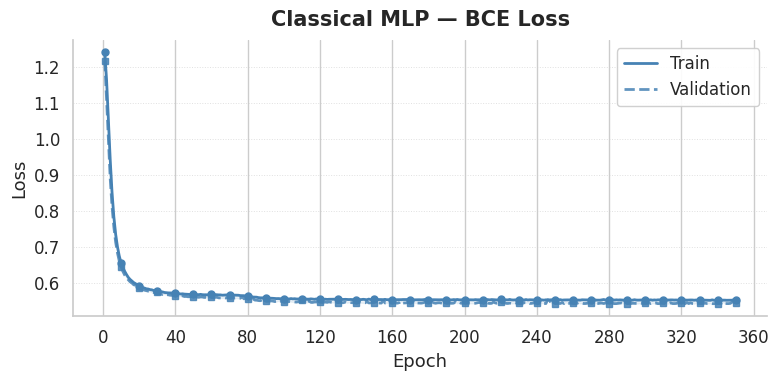

,architecture,trainable_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
0,Classical MLP,77,0.5450,0.7127,0.8162,0.3326,0.8824,0.4831,0.9117,0.5066,0.8109,0.3257,0.8808,0.4756,0.9092,0.4936


In [86]:
from matplotlib.lines import Line2D as _Line2D

# --- Tunable: show a marker every PLOT_MARKER_EVERY epochs to avoid clutter ---
CLASSICAL_PLOT_MARKER_EVERY = 10

_c_epochs = classical_history_df["epoch"].to_numpy()
_c_mask = (
    (_c_epochs % CLASSICAL_PLOT_MARKER_EVERY == 0)
    | (_c_epochs == _c_epochs[0])
    | (_c_epochs == _c_epochs[-1])
)

fig, ax = plt.subplots(figsize=(8, 4))
# Continuous lines (no per-epoch markers)
ax.plot(classical_history_df["epoch"], classical_history_df["train_loss"],
        color="steelblue", linewidth=2.0, label="Train")
ax.plot(classical_history_df["epoch"], classical_history_df["val_loss"],
        color="steelblue", linewidth=2.0, linestyle="--", alpha=0.85, label="Validation")
# Sparse markers at selected epochs
ax.plot(classical_history_df["epoch"][_c_mask], classical_history_df["train_loss"][_c_mask],
        color="steelblue", linestyle="none", marker="o", markersize=5)
ax.plot(classical_history_df["epoch"][_c_mask], classical_history_df["val_loss"][_c_mask],
        color="steelblue", linestyle="none", marker="s", markersize=5, alpha=0.85)
ax.fill_between(
    classical_history_df["epoch"],
    classical_history_df["train_loss"],
    classical_history_df["val_loss"],
    color="steelblue", alpha=0.10,
)
ax.set_title("Classical MLP — BCE Loss", fontsize=15, fontweight="bold", pad=10)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6)
ax.legend(fontsize=12, framealpha=0.92)
plt.tight_layout()
plt.show()

pd.DataFrame([classical_result["summary"]]).round(4)


## 15. Quantum vs Classical Comparison

The table compares the selected QNN depth against the classical MLP. Both rows use the same training, validation, and test tensors, the same positive-class weight, and validation-only threshold tuning. Both models output logits and are trained with `BCEWithLogitsLoss(pos_weight=...)`. The QNN logit comes from a `Linear(n_qubits, 1)` head over per-wire ⟨Z_w⟩ expectations; the MLP logit comes directly from its final linear layer.


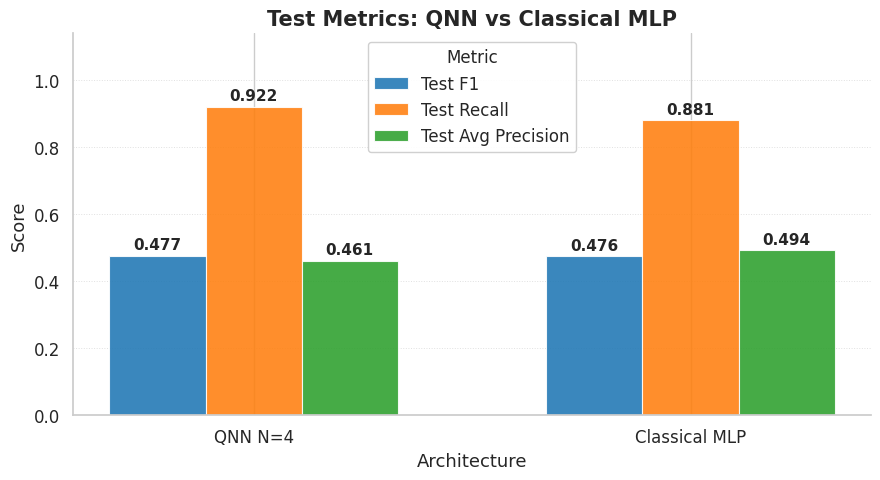

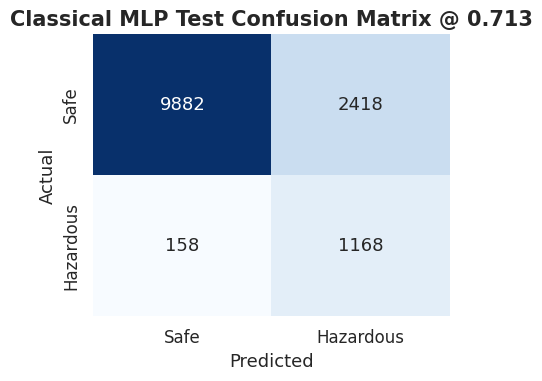

,trainable_parameters,threshold,val_f1,val_recall,val_avg_precision,test_f1,test_recall,test_avg_precision
architecture,,,,,,,,
QNN N=4,144,0.6636,0.4890,0.9344,0.4806,0.4768,0.9216,0.4615
Classical MLP,77,0.7127,0.4831,0.8824,0.5066,0.4756,0.8808,0.4936


In [82]:
architecture_comparison_df = pd.DataFrame(
    [
        {
            "architecture": f"QNN N={best_result['reuploads']}",
            "trainable_parameters": best_result["summary"]["quantum_parameters"],
            "threshold": best_result["threshold"],
            "val_f1": best_result["summary"]["val_f1"],
            "val_recall": best_result["summary"]["val_recall"],
            "val_avg_precision": best_result["summary"]["val_avg_precision"],
            "test_f1": best_result["summary"]["test_f1"],
            "test_recall": best_result["summary"]["test_recall"],
            "test_avg_precision": best_result["summary"]["test_avg_precision"],
        },
        {
            "architecture": "Classical MLP",
            "trainable_parameters": classical_result["summary"]["trainable_parameters"],
            "threshold": classical_result["threshold"],
            "val_f1": classical_result["summary"]["val_f1"],
            "val_recall": classical_result["summary"]["val_recall"],
            "val_avg_precision": classical_result["summary"]["val_avg_precision"],
            "test_f1": classical_result["summary"]["test_f1"],
            "test_recall": classical_result["summary"]["test_recall"],
            "test_avg_precision": classical_result["summary"]["test_avg_precision"],
        },
    ]
).set_index("architecture")

_metrics_to_plot = ["test_f1", "test_recall", "test_avg_precision"]
_metric_labels  = ["Test F1", "Test Recall", "Test Avg Precision"]
_archs          = architecture_comparison_df.index.tolist()

_x         = np.arange(len(_archs))
_n         = len(_metrics_to_plot)
_bw        = 0.22
_offsets   = np.linspace(-(_n - 1) / 2 * _bw, (_n - 1) / 2 * _bw, _n)
_colors    = [plt.cm.tab10.colors[i] for i in range(_n)]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (metric, label, color) in enumerate(zip(_metrics_to_plot, _metric_labels, _colors)):
    vals = architecture_comparison_df[metric].values
    bars = ax.bar(
        _x + _offsets[i], vals, width=_bw,
        label=label, color=color, alpha=0.88,
        edgecolor="white", linewidth=0.8,
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.010,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold",
        )

ax.set_xticks(_x)
ax.set_xticklabels(_archs)
ax.set_ylim(0, 1.14)
ax.set_title("Test Metrics: QNN vs Classical MLP", fontweight="bold")
ax.set_xlabel("Architecture")
ax.set_ylabel("Score")
ax.legend(title="Metric", framealpha=0.92)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.show()

plot_confusion_matrix(
    y_te_qnn,
    classical_result["test"]["y_pred"],
    f"Classical MLP Test Confusion Matrix @ {classical_result['threshold']:.3f}",
)

architecture_comparison_df.round(4)


In [87]:
# Temporary: print thresholds for all architectures
for r in experiment_results:
    print(f"N={r['reuploads']}: threshold={r['threshold']:.4f}, val_f1={r['summary']['val_f1']:.4f}, test_f1={r['summary']['test_f1']:.4f}")

N=1: threshold=0.6506, val_f1=0.4815, test_f1=0.4725
N=2: threshold=0.5877, val_f1=0.4775, test_f1=0.4719
N=3: threshold=0.6887, val_f1=0.4819, test_f1=0.4745
N=4: threshold=0.6636, val_f1=0.4890, test_f1=0.4768
